In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import re
import json
from sklearn.preprocessing import MinMaxScaler
from math import pi
from datetime import timedelta
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from statsmodels.tsa.seasonal import seasonal_decompose

from Tools import Tools4DataExtraction as T4DE

In [2]:
D4NN= T4DE.Get_Data4NN_p()
atributo='FECHA_CORRIDA'
D4NN[atributo] = pd.to_datetime(D4NN[atributo])
fecha_maxima = D4NN[atributo].max()
dia_anterior = fecha_maxima - timedelta(days=1)
"""
fecha_inicio = dia_anterior - timedelta(days=364)
D4NN = D4NN[(D4NN[atributo] >= fecha_inicio) &
                    (D4NN[atributo] <= dia_anterior)].copy()
"""
D4NN = D4NN[(D4NN[atributo] <= dia_anterior)].copy()

Memoria usada antes: 632.54 MB
Memoria usada después: 122.86 MB
Reducción: 80.6%


In [3]:
df= D4NN[['FECHA_CORRIDA','BOLETOS_VEND', 'HORAS_ANTICIPACION','DIF_TARIF','PORCENT_PROMO','FOP','AÑO', 'MES']].copy()

In [4]:
agg_dict = {col: 'mean' for col in df.columns if col not in ['FECHA_CORRIDA','BOLETOS_VEND','VENTA']}
agg_dict['BOLETOS_VEND'] = 'sum'
#agg_dict['VENTA'] = 'sum'

df_group = df.groupby('FECHA_CORRIDA').agg(agg_dict).reset_index()

df_group['DiaSemana']=pd.to_datetime(df_group['FECHA_CORRIDA']).dt.dayofweek

In [5]:
df_group

,FECHA_CORRIDA,HORAS_ANTICIPACION,DIF_TARIF,PORCENT_PROMO,FOP,AÑO,MES,BOLETOS_VEND,DiaSemana
0,2023-01-01,4.526946,0.702678,10.714286,0.854763,2023.0,1.0,167.0,6
1,2023-01-02,12.369099,0.743035,10.194175,0.695128,2023.0,1.0,233.0,0
2,2023-01-03,16.901235,0.719514,10.877863,0.755617,2023.0,1.0,486.0,1
3,2023-01-04,14.161702,0.708217,10.199005,0.708875,2023.0,1.0,470.0,2
4,2023-01-05,14.641844,0.660707,10.185185,0.434043,2023.0,1.0,282.0,3
...,...,...,...,...,...,...,...,...,...
1047,2025-11-13,100.135338,0.735536,3.897059,0.681078,2025.0,11.0,133.0,3
1048,2025-11-14,140.270000,0.762621,4.192307,0.738750,2025.0,11.0,200.0,4
1049,2025-11-15,77.791667,0.712522,3.984375,0.618827,2025.0,11.0,144.0,5
1050,2025-11-16,78.330645,0.723185,4.126984,0.536962,2025.0,11.0,124.0,6


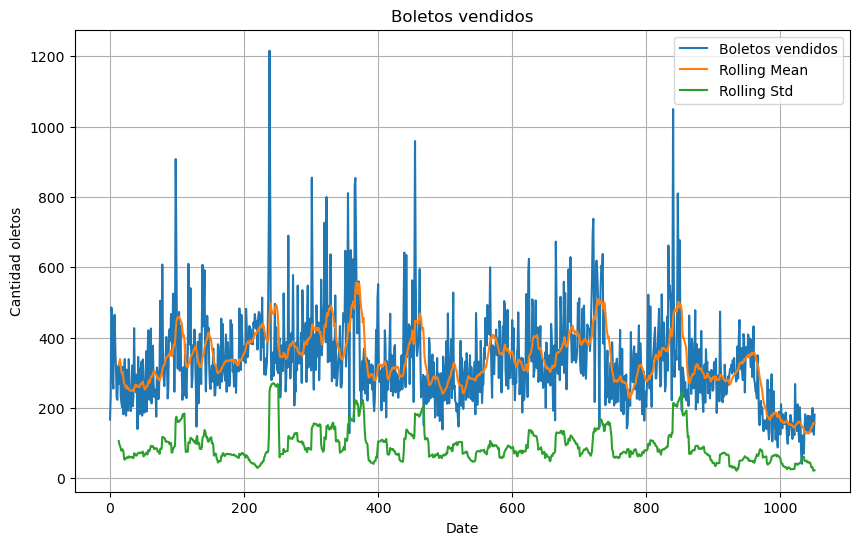

In [6]:
# Calculate the rolling mean and standard deviation
rolling_mean = df_group['BOLETOS_VEND'].rolling(window=14).mean()
rolling_std = df_group['BOLETOS_VEND'].rolling(window=14).std()

# Plot the rolling mean and standard deviation
plt.figure(figsize=(10, 6))
plt.plot( df_group['BOLETOS_VEND'], label="Boletos vendidos")
plt.plot( rolling_mean, label="Rolling Mean")
plt.plot( rolling_std, label="Rolling Std")
plt.xlabel("Date")
plt.ylabel("Cantidad oletos")
plt.title("Boletos vendidos")
plt.legend()
plt.grid(True)

plt.show()

In [7]:
def Get_goodCarac(Df,BC_json):
    df=Df.copy()
    df['DiaMayorBoletaje'] = df['DiaSemana'].isin(BC_json["DiaBueno"])
    df['MesMayorBoletaje'] = df['MES'].isin(BC_json["MesBueno"])
    return df

In [8]:
ruta_principal = os.getcwd()
BuenasCarac_path = os.path.join(ruta_principal, "Files", "BuenaCaracteristicas.json")
with open(BuenasCarac_path, 'r') as f:
    #  Cargar el contenido del archivo JSON
    BC_json = json.load(f)
    
df_group= Get_goodCarac(df_group,BC_json)

In [9]:
df_group

,FECHA_CORRIDA,HORAS_ANTICIPACION,DIF_TARIF,PORCENT_PROMO,FOP,AÑO,MES,BOLETOS_VEND,DiaSemana,DiaMayorBoletaje,MesMayorBoletaje
0,2023-01-01,4.526946,0.702678,10.714286,0.854763,2023.0,1.0,167.0,6,True,True
1,2023-01-02,12.369099,0.743035,10.194175,0.695128,2023.0,1.0,233.0,0,True,True
2,2023-01-03,16.901235,0.719514,10.877863,0.755617,2023.0,1.0,486.0,1,False,True
3,2023-01-04,14.161702,0.708217,10.199005,0.708875,2023.0,1.0,470.0,2,False,True
4,2023-01-05,14.641844,0.660707,10.185185,0.434043,2023.0,1.0,282.0,3,False,True
...,...,...,...,...,...,...,...,...,...,...,...
1047,2025-11-13,100.135338,0.735536,3.897059,0.681078,2025.0,11.0,133.0,3,False,False
1048,2025-11-14,140.270000,0.762621,4.192307,0.738750,2025.0,11.0,200.0,4,True,False
1049,2025-11-15,77.791667,0.712522,3.984375,0.618827,2025.0,11.0,144.0,5,False,False
1050,2025-11-16,78.330645,0.723185,4.126984,0.536962,2025.0,11.0,124.0,6,True,False


In [10]:
df=df_group.copy()
df = df.set_index('FECHA_CORRIDA')
# Asegurarse de que el índice sea de tipo datetime y que el DataFrame esté ordenado
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# Columna Target original para referencia
target_col = 'BOLETOS_VEND'

# 1. 📝 Preparación de la Data y Codificación

In [11]:
# Mapeo para nombres de días (opcional, para mayor claridad)
dias_semana = {0: 'Lunes', 1: 'Martes', 2: 'Miercoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sabado', 6: 'Domingo'}
df['DiaSemana_Nombre'] = df['DiaSemana'].map(dias_semana)
df=df.drop(columns='DiaSemana',axis=1)
# 1.2. Codificación del Día de la Semana (OHE)
# Usamos 'drop_first=False' para mantener todos los días
df = pd.get_dummies(df, columns=['DiaSemana_Nombre'], prefix='Dia', drop_first=False)

# 1.3. Codificación de Mes (OHE)
# La columna MES debe ser tratada como categórica antes del OHE
df['MES'] = df['MES'].astype(int)
df = pd.get_dummies(df, columns=['MES'], prefix='Mes', drop_first=False)

# 2. 📈 Ingeniería de Características Clave (Tendencia y Volatilidad)

In [12]:
# Definición de ventanas de tiempo
ventanas = [14, 30]

for ventana in ventanas:
    # Media Móvil (Tendencia)
    df[f'MM_{ventana}D'] = df[target_col].rolling(window=ventana).mean().shift(1)
    
    # Desviación Estándar (Volatilidad)
    # Esta es la señal directa de volatilidad reciente
    df[f'StdDev_{ventana}D'] = df[target_col].rolling(window=ventana).std().shift(1)

In [13]:
#df = df.asfreq('D')  # Cambia D a M, H, etc., si corresponde

# Descomposición (elige modelo: 'additive' o 'multiplicative')
result = seasonal_decompose(df[target_col], model='additive', period=14)  

# Componentes
df['trend']     = result.trend
df['seasonal']  = result.seasonal
#df['residual']  = result.resid

In [14]:
# Retraso Semanal (Estacionalidad semanal)
df['Boletos_t-7'] = df[target_col].shift(7)

# Retraso de Promoción (Causalidad)
df['Promo_t-1'] = df['PORCENT_PROMO'].shift(1)

# Se recomienda rellenar los valores NaN introducidos por los shifts/rolling,
# ya sea eliminando las primeras filas o rellenándolos con 0 o la media
# Los NaN se generarán en las primeras 7 o 30 filas.
df = df.dropna()

# Mostrar las nuevas características (opcional)
print(f"Número total de features después de la Ingeniería: {df.shape[1]}")

Número total de features después de la Ingeniería: 35


# 3. 🎯 Pre-procesamiento Final (Target)

In [15]:
# 3. Diferenciación (Transformación del Target)
# Creamos la variable Y't: el cambio de boletos vendidos
df['BOLETOS_VEND_DIF'] = df[target_col].diff()

# Al aplicar .diff(), se introduce un nuevo NaN en la primera fila.
# Si ya eliminamos los NaN del rolling/shift (paso 2.2), esta fila también debe ser eliminada
df = df.dropna()

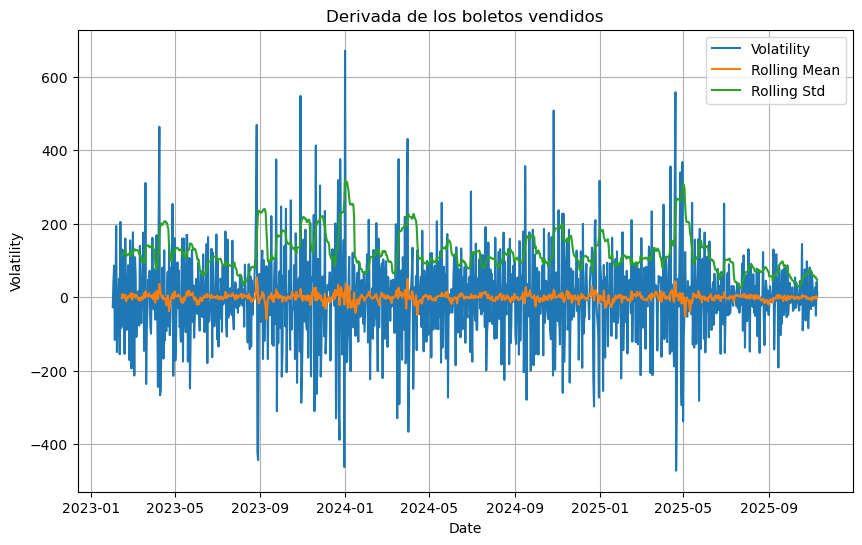

In [16]:
# Calculate the rolling mean and standard deviation
rolling_mean = df['BOLETOS_VEND_DIF'].rolling(window=14).mean()
rolling_std = df['BOLETOS_VEND_DIF'].rolling(window=14).std()

# Plot the rolling mean and standard deviation
plt.figure(figsize=(10, 6))
plt.plot( df['BOLETOS_VEND_DIF'], label="Volatility")
plt.plot( rolling_mean, label="Rolling Mean")
plt.plot( rolling_std, label="Rolling Std")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title("Derivada de los boletos vendidos")
plt.legend()
plt.grid(True)

plt.show()

In [17]:
df.columns

Index(['HORAS_ANTICIPACION', 'DIF_TARIF', 'PORCENT_PROMO', 'FOP', 'AÑO',
       'BOLETOS_VEND', 'DiaMayorBoletaje', 'MesMayorBoletaje', 'Dia_Domingo',
       'Dia_Jueves', 'Dia_Lunes', 'Dia_Martes', 'Dia_Miercoles', 'Dia_Sabado',
       'Dia_Viernes', 'Mes_1', 'Mes_2', 'Mes_3', 'Mes_4', 'Mes_5', 'Mes_6',
       'Mes_7', 'Mes_8', 'Mes_9', 'Mes_10', 'Mes_11', 'Mes_12', 'MM_14D',
       'StdDev_14D', 'MM_30D', 'StdDev_30D', 'trend', 'seasonal',
       'Boletos_t-7', 'Promo_t-1', 'BOLETOS_VEND_DIF'],
      dtype='object')

In [18]:
df.to_csv('Data4LSTM.csv')

In [19]:
df.columns

Index(['HORAS_ANTICIPACION', 'DIF_TARIF', 'PORCENT_PROMO', 'FOP', 'AÑO',
       'BOLETOS_VEND', 'DiaMayorBoletaje', 'MesMayorBoletaje', 'Dia_Domingo',
       'Dia_Jueves', 'Dia_Lunes', 'Dia_Martes', 'Dia_Miercoles', 'Dia_Sabado',
       'Dia_Viernes', 'Mes_1', 'Mes_2', 'Mes_3', 'Mes_4', 'Mes_5', 'Mes_6',
       'Mes_7', 'Mes_8', 'Mes_9', 'Mes_10', 'Mes_11', 'Mes_12', 'MM_14D',
       'StdDev_14D', 'MM_30D', 'StdDev_30D', 'trend', 'seasonal',
       'Boletos_t-7', 'Promo_t-1', 'BOLETOS_VEND_DIF'],
      dtype='object')

# 4. 🗂️ Preparación Final para la LSTM

In [20]:
# 1. Definir la variable Target (Y) diferenciada
Y = df['BOLETOS_VEND_DIF'].values

# 2. Definir las Features (X)
# Excluir las variables que no son features (la original, la diferenciada, y variables temporales que ya codificamos)

features_a_excluir = [
    'FECHA_CORRIDA',      # Si fuera una columna, no el índice
    target_col,           # Target original
    'BOLETOS_VEND_DIF' ,   # Nuevo Target
]

# Seleccionar solo las columnas numéricas que serán features
X_cols = [col for col in df.columns if col not in features_a_excluir]
X = df[X_cols].values

# 3. Escalamiento de Datos (CRÍTICO para LSTM)
scaler_X = MinMaxScaler()
scaler_Y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
Y_scaled = scaler_Y.fit_transform(Y.reshape(-1, 1)) # Debe ser un array 2D para el scaler

print(f"\nDimensiones de X (Features escaladas): {X_scaled.shape}")
print(f"Dimensiones de Y (Target diferenciado y escalado): {Y_scaled.shape}")


Dimensiones de X (Features escaladas): (1014, 34)
Dimensiones de Y (Target diferenciado y escalado): (1014, 1)


# 5. ⚙️ Configuración y Creación de Secuencias

In [21]:
# --- PARÁMETROS CLAVE ---
# 1. Ventana de tiempo que la LSTM observará para hacer la predicción
TIMESTEPS = 30  

# 2. Proporción para dividir el set de entrenamiento y prueba
TEST_SIZE = 0.20

In [22]:
def create_sequences(X, y, timesteps):
    """
    Crea secuencias de tiempo (timesteps) para la entrada de la LSTM.
    
    Args:
        X (np.array): Features escaladas [días, features]
        y (np.array): Target escalado [días, 1]
        timesteps (int): Longitud de la secuencia de tiempo (ej. 7 días)
        
    Returns:
        np.array: X_seq (Features 3D)
        np.array: y_seq (Target asociado)
    """
    X_seq, y_seq = [], []
    
    for i in range(len(X) - timesteps):
        # La secuencia X_seq va desde i hasta i + timesteps.
        X_seq.append(X[i:(i + timesteps), :])
        
        # El valor Y_seq es el siguiente valor (el que viene después de la secuencia).
        # Recuerda que 'y' ya es la diferencia de boletos.
        y_seq.append(y[i + timesteps])
        
    return np.array(X_seq), np.array(y_seq)

# Aplicar la función a tus datos escalados
X_seq, Y_seq = create_sequences(X_scaled, Y_scaled, TIMESTEPS)

print(f"Forma de X_seq (muestras, timesteps, features): {X_seq.shape}")
print(f"Forma de Y_seq (muestras, 1): {Y_seq.shape}")

Forma de X_seq (muestras, timesteps, features): (984, 30, 34)
Forma de Y_seq (muestras, 1): (984, 1)


# 6. 🧱 División y Arquitectura del Modelo

In [23]:
# División cronológica de los datos
# np.ceil asegura que el número de muestras sea un entero
split_point = int(np.ceil(len(X_seq) * (1 - TEST_SIZE)))

X_train, X_test = X_seq[:split_point], X_seq[split_point:]
y_train, y_test = Y_seq[:split_point], Y_seq[split_point:]

print(f"Muestras de Entrenamiento: {X_train.shape[0]}")
print(f"Muestras de Prueba: {X_test.shape[0]}")

# --- PARÁMETROS DEL MODELO ---
# El número de features es la última dimensión de X_train
num_features = X_train.shape[2] 
# El timestep es la dimensión media
num_timesteps = X_train.shape[1] 

Muestras de Entrenamiento: 788
Muestras de Prueba: 196


In [24]:
"""
# PRIMER ESTRUCTURA
# 1. Definición del Modelo
model = Sequential([
    # Primera capa LSTM: retorna secuencias (return_sequences=True) para alimentar a la siguiente LSTM
    LSTM(units=100, 
         activation='relu', # ReLU es común, aunque otros como tanh también funcionan bien
         return_sequences=True, 
         input_shape=(num_timesteps, num_features)),
    Dropout(0.3), # Regularización: apaga el 30% de las neuronas al azar para evitar overfitting

    # Segunda capa LSTM: no retorna secuencias, solo el output final para la capa Dense
    LSTM(units=200, activation='relu'),
    Dropout(0.3), # Segunda capa de regularización

    # Capa de salida: una sola unidad, ya que predices un solo valor (la diferencia)
    Dense(units=1)
])

# 2. Compilación del Modelo
# Usamos MSE (Mean Squared Error) ya que penaliza fuertemente los errores grandes (picos de volatilidad)
model.compile(optimizer='adam', loss='mse', metrics=['mae']) 

# Resumen de la arquitectura
model.summary()

# 3. Entrenamiento (¡Ejecuta este bloque!)
print("\nIniciando Entrenamiento del Modelo...")

history = model.fit(
    X_train, y_train,
    epochs=50,             # Número de pasadas completo
    batch_size=32,         # Tamaño del lote
    validation_data=(X_test, y_test),
    verbose=0              # Muestra el progreso
)

# Evaluar el modelo entrenado
loss, mae = model.evaluate(X_test, y_test, verbose=0)

# Predecir sobre el conjunto de prueba
y_pred_scaled = model.predict(X_test)

# Cálculo de la R cuadrada (R2)
r2 = r2_score(y_test, y_pred_scaled)

print("\n--- Resultados de la Evaluación en el Set de Prueba ---")
print(f"Pérdida (MSE) en prueba: {loss:.4f}")
print(f"MAE (Error Absoluto Medio) en prueba: {mae:.4f}")
print(f"R cuadrada (R2) en prueba: {r2:.4f}")
"""

'\n# PRIMER ESTRUCTURA\n# 1. Definición del Modelo\nmodel = Sequential([\n    # Primera capa LSTM: retorna secuencias (return_sequences=True) para alimentar a la siguiente LSTM\n    LSTM(units=100, \n         activation=\'relu\', # ReLU es común, aunque otros como tanh también funcionan bien\n         return_sequences=True, \n         input_shape=(num_timesteps, num_features)),\n    Dropout(0.3), # Regularización: apaga el 30% de las neuronas al azar para evitar overfitting\n\n    # Segunda capa LSTM: no retorna secuencias, solo el output final para la capa Dense\n    LSTM(units=200, activation=\'relu\'),\n    Dropout(0.3), # Segunda capa de regularización\n\n    # Capa de salida: una sola unidad, ya que predices un solo valor (la diferencia)\n    Dense(units=1)\n])\n\n# 2. Compilación del Modelo\n# Usamos MSE (Mean Squared Error) ya que penaliza fuertemente los errores grandes (picos de volatilidad)\nmodel.compile(optimizer=\'adam\', loss=\'mse\', metrics=[\'mae\']) \n\n# Resumen de l

In [25]:
"""
# SEGUNDA ESTRUCTURA
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

model = Sequential([
    # Mayor capacidad y activación 'tanh' para centrar en la diferencia
    LSTM(units=128, activation='tanh', return_sequences=True, 
         input_shape=(num_timesteps, num_features)),
    Dropout(0.15), # Dropout reducido para permitir más señal (menos suavizado)
    
    LSTM(units=80, activation='tanh'),
    Dropout(0.15), 

    Dense(units=1)
])

# 4. Compilación con Pérdida de Huber y Learning Rate ajustado
custom_optimizer = Adam(learning_rate=0.0005) # Learning rate reducido

model.compile(optimizer=custom_optimizer, 
              loss=Huber(delta=1.0), 
              metrics=['mae']) 

# 5. Entrenamiento
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\nIniciando Re-entrenamiento del Modelo Ajustado...")
history = model.fit(
    X_train, y_train,
    epochs=100,             
    batch_size=32,          
    validation_data=(X_test, y_test),
    callbacks=[early_stopping], 
    verbose=0              
)

# 6. Evaluación
loss, mae = model.evaluate(X_test, y_test, verbose=0)
y_pred_scaled = model.predict(X_test)
r2 = r2_score(y_test, y_pred_scaled)

print("\n--- Resultados del Modelo Ajustado ---")
print(f"Pérdida (Huber Loss) en prueba: {loss:.4f}")
print(f"MAE en prueba: {mae:.4f}")
print(f"R cuadrada (R2) en prueba: {r2:.4f}")
"""

'\n# SEGUNDA ESTRUCTURA\nimport numpy as np\nimport tensorflow as tf\nfrom tensorflow.keras.models import Sequential\nfrom tensorflow.keras.layers import LSTM, Dense, Dropout\nfrom tensorflow.keras.optimizers import Adam\nfrom tensorflow.keras.losses import Huber\nfrom tensorflow.keras.callbacks import EarlyStopping\nfrom sklearn.metrics import r2_score\nfrom sklearn.model_selection import train_test_split\n\nmodel = Sequential([\n    # Mayor capacidad y activación \'tanh\' para centrar en la diferencia\n    LSTM(units=128, activation=\'tanh\', return_sequences=True, \n         input_shape=(num_timesteps, num_features)),\n    Dropout(0.15), # Dropout reducido para permitir más señal (menos suavizado)\n    \n    LSTM(units=80, activation=\'tanh\'),\n    Dropout(0.15), \n\n    Dense(units=1)\n])\n\n# 4. Compilación con Pérdida de Huber y Learning Rate ajustado\ncustom_optimizer = Adam(learning_rate=0.0005) # Learning rate reducido\n\nmodel.compile(optimizer=custom_optimizer, \n          

In [26]:
#"""
# TERCERA ESTRUCTURA (Ajustada para cálculo de RMSE)
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
# Importamos la función MSE de scikit-learn
from sklearn.metrics import r2_score, mean_squared_error 
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# NOTA: Debes asegurar que las variables X_train, y_train, X_test, y_test, 
# num_timesteps, y num_features estén definidas en tu entorno de trabajo.

model = Sequential([
    # 1. Primera Capa LSTM: Mayor capacidad y 'tanh'
    LSTM(units=256, activation='tanh', return_sequences=True, 
         input_shape=(num_timesteps, num_features)),
    Dropout(0.2), 

    # 2. Segunda Capa LSTM: Intermedia, mantiene return_sequences=True
    LSTM(units=128, activation='tanh', return_sequences=True),
    Dropout(0.2), 

    # 3. Tercera Capa LSTM: Más pequeña, no retorna secuencias (output final)
    LSTM(units=60, activation='tanh'),
    Dropout(0.2), 

    # Capa de salida
    Dense(units=1)
])

# 4. Compilación con Pérdida de Huber y Learning Rate ajustado
custom_optimizer = Adam(learning_rate=0.0005) 

model.compile(optimizer=custom_optimizer, 
              loss=Huber(delta=1.0), # Huber Loss
              metrics=['mae']) # Mantenemos MAE como métrica de entrenamiento

# 5. Entrenamiento
early_stopping = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True)

print("\nIniciando Entrenamiento de la TERCERA ESTRUCTURA...")

history = model.fit(
    X_train, y_train,
    epochs=100,             
    batch_size=32,          
    validation_data=(X_test, y_test),
    callbacks=[early_stopping], 
    verbose=0              
)

# 6. Evaluación
# Obtener el MAE directamente de la evaluación de Keras
loss_huber, mae = model.evaluate(X_test, y_test, verbose=0) 

# Realizar la predicción en el set de prueba
y_pred_scaled = model.predict(X_test)

# --- Cálculo de Métricas Adicionales (RMSE y R2) ---

# Calcular el MSE y luego la raíz cuadrada para obtener el RMSE
mse = mean_squared_error(y_test, y_pred_scaled)
rmse = np.sqrt(mse)

# Calcular el R cuadrada (R2)
r2 = r2_score(y_test, y_pred_scaled)

print("\n--- Resultados de la TERCERA ESTRUCTURA ---")
print(f"Pérdida (Huber Loss) en prueba: {loss_huber:.4f}")
print(f"MAE (Error Absoluto Medio) en prueba: {mae:.4f}")
print(f"RMSE (Raíz del Error Cuadrático Medio) en prueba: {rmse:.4f}")
print(f"R cuadrada (R2) en prueba: {r2:.4f}")

#"""


Iniciando Entrenamiento de la TERCERA ESTRUCTURA...
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step

--- Resultados de la TERCERA ESTRUCTURA ---
Pérdida (Huber Loss) en prueba: 0.0021
MAE (Error Absoluto Medio) en prueba: 0.0474
RMSE (Raíz del Error Cuadrático Medio) en prueba: 0.0653
R cuadrada (R2) en prueba: 0.2530


# 7. 📉 Des-Escalamiento y Re-Integración

In [27]:
# 1. Des-Escalar las Predicciones (de 0-1 a la escala de la diferencia de boletos)
y_pred_dif = scaler_Y.inverse_transform(y_pred_scaled)
# y_pred_dif ahora es el pronóstico de la diferencia de boletos (Y't)

# 2. Des-Escalar los Valores Reales (para calcular el error en la escala original)
y_test_dif_real = scaler_Y.inverse_transform(y_test)
# y_test_dif_real es el valor real de la diferencia de boletos

# --- Re-Integración ---
# Recordar que la división del set de prueba comienza en 'split_point' y tiene el tamaño de X_test

# Obtener la serie de tiempo original de boletos vendidos, excluyendo los timesteps iniciales
# La variable 'df' contiene los datos completos (ya limpios de NaN iniciales).
# Identificamos el punto de inicio real en el DataFrame para las pruebas.
start_index = df.shape[0] - X_test.shape[0]

# El valor real de los Boletos Vendidos (Y_t) que queremos predecir (sin diferenciar)
boletos_reales_test = df['BOLETOS_VEND'].iloc[start_index:].values

# El valor anterior (Y_{t-1}) necesario para re-integrar (Boletos vendidos de ayer)
# Usamos el valor real de BOLETOS_VEND, con un retraso de 1 día
boletos_ayer_test = df['BOLETOS_VEND'].iloc[start_index - 1 : -1].values
# Asegúrate de que boletos_ayer_test tenga la misma longitud que y_pred_dif

# 3. Re-Integración: Ŷ_t = Ŷ'_t + Y_{t-1}
# Pronóstico de Boletos Vendidos (sin diferenciar)
y_pred_reintegrado = y_pred_dif.flatten() + boletos_ayer_test

# 4. Los Valores Reales (Y_t) para la comparación
y_test_reales = boletos_reales_test[:len(y_pred_reintegrado)]

print("\n--- Resultados de Des-Escalamiento y Re-Integración ---")
print(f"Predicción (Y_t): {y_pred_reintegrado[:5]}")
print(f"Real (Y_t): {y_test_reales[:5]}")


--- Resultados de Des-Escalamiento y Re-Integración ---
Predicción (Y_t): [493.83435 306.66507 701.57336 349.6883  176.67282]
Real (Y_t): [309. 677. 339. 228. 192.]


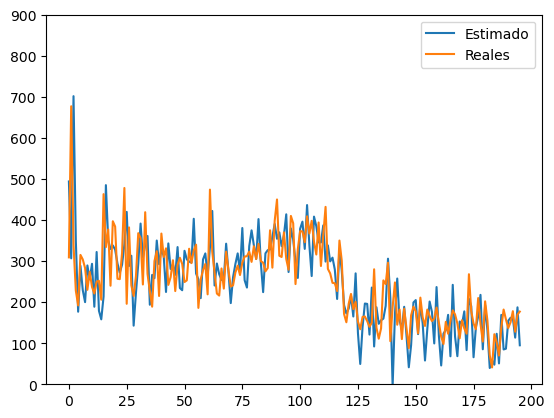

In [28]:
plt.plot(y_pred_reintegrado,label='Estimado')
plt.plot(y_test_reales,label='Reales')
plt.ylim([0,900])
plt.legend()
plt.show()

In [29]:
# Cálculo de los Residuales (Errores del Modelo LSTM)
# Estos residuales son la serie que será utilizada como input para el modelo GARCH.

residuales = y_test_reales - y_pred_reintegrado

print("\n--- Residuales (Errores de la LSTM) ---")
print(f"Residuales (e_t) generados para GARCH: {residuales[:5]}")
print(f"Longitud de la serie de Residuales: {len(residuales)}")


--- Residuales (Errores de la LSTM) ---
Residuales (e_t) generados para GARCH: [-184.83435   370.33493  -362.57336  -121.68829    15.327179]
Longitud de la serie de Residuales: 196


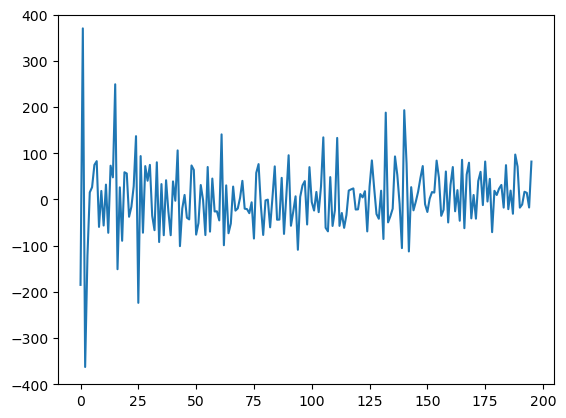

In [30]:
plt.plot(residuales)
plt.ylim([-400,400])
plt.show()

# 8💻 Modelado GARCH(1,1)

In [31]:
from arch import arch_model

# Asumimos que la variable 'residuales' (el error del LSTM) es un array 1D
# Si 'residuales' es un objeto Pandas Series, el código funciona directamente.
# Si es un numpy array, asegúrate de que es un array 1D:
residuales = residuales.flatten()

### Definición y Ajuste del Modelo GARCH(1,1)

In [32]:
print("\nIniciando Modelado GARCH(1,1) en los Residuales...")

# 1. Definir el modelo GARCH
# mean='zero' es CRUCIAL porque la LSTM ya modeló la media, 
# y los residuales deben tener media cero.
am = arch_model(residuales, mean='zero', vol='Garch', p=1, q=1)

# 2. Ajustar el modelo a los datos (Entrenamiento)
# disp='off' suprime los mensajes de optimización
res = am.fit(disp='off')

# 3. Mostrar el resumen de los resultados del modelo
print(res.summary())


Iniciando Modelado GARCH(1,1) en los Residuales...
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.005
Vol Model:                      GARCH   Log-Likelihood:               -1096.73
Distribution:                  Normal   AIC:                           2199.47
Method:            Maximum Likelihood   BIC:                           2209.30
                                        No. Observations:                  196
Date:                Tue, Nov 18 2025   Df Residuals:                      196
Time:                        12:03:04   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega 

### Pronóstico de Volatilidad (Varianza Condicional)

In [33]:
# Realizamos un pronóstico de 5 días de la varianza (volatilidad)
horizon = 5 
forecasts = res.forecast(horizon=horizon)

# La varianza condicional es el pronóstico de la volatilidad al cuadrado (σ^2)
varianza_pronosticada = forecasts.variance.values[-1]

print(f"\n--- Pronóstico de Volatilidad (Varianza Condicional) para los próximos {horizon} días ---")
# La fila 'h.1' es el pronóstico del día siguiente, 'h.2' el subsiguiente, y así sucesivamente.
for i in range(horizon):
    # La raíz cuadrada de la varianza nos da la Desviación Estándar (la volatilidad)
    volatilidad_std = np.sqrt(varianza_pronosticada[i])
    print(f"Día t+{i+1}: Varianza (σ²): {varianza_pronosticada[i]:.2f} | Volatilidad (σ): {volatilidad_std:.2f}")


--- Pronóstico de Volatilidad (Varianza Condicional) para los próximos 5 días ---
Día t+1: Varianza (σ²): 5643.03 | Volatilidad (σ): 75.12
Día t+2: Varianza (σ²): 5192.39 | Volatilidad (σ): 72.06
Día t+3: Varianza (σ²): 5005.23 | Volatilidad (σ): 70.75
Día t+4: Varianza (σ²): 4927.50 | Volatilidad (σ): 70.20
Día t+5: Varianza (σ²): 4895.22 | Volatilidad (σ): 69.97


# 9 📊 Creación del Intervalo de Confianza (El Resultado Final)

In [34]:
# Pronóstico de la Media: Usamos el último valor pronosticado por la LSTM (para t)
# En un escenario real, deberías correr la predicción de la LSTM para t+1 con las features de t+1
# Aquí usaremos el último valor de la predicción de prueba solo para ilustrar el cálculo.
ultimo_pronostico_lstm = y_pred_reintegrado[-1] 
volatilidad_t_plus_1 = np.sqrt(varianza_pronosticada[0]) # Volatilidad para el día siguiente (h.1)
Z_score_95 = 1.96

limite_inferior = ultimo_pronostico_lstm - (Z_score_95 * volatilidad_t_plus_1)
limite_superior = ultimo_pronostico_lstm + (Z_score_95 * volatilidad_t_plus_1)

print("\n--- Intervalo de Confianza para el Día Siguiente (95%) ---")
print(f"Predicción de Ventas (Media): {ultimo_pronostico_lstm:.0f} boletos")
print(f"Volatilidad (σ) Estimada por GARCH: {volatilidad_t_plus_1:.2f}")
print(f"Intervalo de Confianza [Ventas]: [{limite_inferior:.0f}, {limite_superior:.0f}]")


--- Intervalo de Confianza para el Día Siguiente (95%) ---
Predicción de Ventas (Media): 95 boletos
Volatilidad (σ) Estimada por GARCH: 75.12
Intervalo de Confianza [Ventas]: [-52, 242]


In [35]:
#D4NN.to_csv("DatosCrudo4NN.csv")

In [36]:
#df_agregado.to_csv('Data4LSTM.csv')